In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar datos
df = pd.read_csv(r'C:\Users\jenar\!clases\TC2004B-Jenaro\data\housing_messy.csv')

In [3]:
df['price_bin'] = pd.qcut(df['price'], q=4, labels=False)
X = df.drop(['price', 'price_bin'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=df['price_bin']
)

In [4]:
# --- MODELO A: Ridge con alpha=0.1 ---
pipe_a = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.1))
])
pipe_a.fit(X_train, y_train)
pred_a = pipe_a.predict(X_test)

# --- MODELO B: Ridge con alpha=10 ---
pipe_b = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10))
])
pipe_b.fit(X_train, y_train)
pred_b = pipe_b.predict(X_test)

# --- MODELO C: Lasso con alpha=5 ---
pipe_c = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=5))
])
pipe_c.fit(X_train, y_train)
pred_c = pipe_c.predict(X_test)

# --- MODELO D: Ridge sin casas de ultra-lujo ---
mask_train = y_train < 1000  # Solo casas <$1M
mask_test = y_test < 1000

pipe_d = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1))
])
pipe_d.fit(X_train[mask_train], y_train[mask_train])
pred_d = pipe_d.predict(X_test[mask_test])

In [6]:
# Función para calcular métricas
def evaluate_model(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    
    # MAPE (cuidado con valores pequeños)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"MAPE: {mape:.2f}%")
    
    # Percentil 95 del error absoluto
    p95 = np.percentile(np.abs(y_true - y_pred), 95)
    print(f"95th percentile |error|: {p95:.2f}")

# Evaluar todos
evaluate_model(y_test, pred_a, "Modelo A: Ridge(alpha=0.1)")
evaluate_model(y_test, pred_b, "Modelo B: Ridge(alpha=10)")
evaluate_model(y_test, pred_c, "Modelo C: Lasso(alpha=5)")
evaluate_model(y_test[mask_test], pred_d, "Modelo D: Ridge sin casas de lujo")


=== Modelo A: Ridge(alpha=0.1) ===
RMSE: 335.22
MAE: 227.70
R2: 0.807
MAPE: 112.58%
95th percentile |error|: 490.04

=== Modelo B: Ridge(alpha=10) ===
RMSE: 339.62
MAE: 223.67
R2: 0.802
MAPE: 107.28%
95th percentile |error|: 454.63

=== Modelo C: Lasso(alpha=5) ===
RMSE: 336.36
MAE: 224.64
R2: 0.805
MAPE: 109.77%
95th percentile |error|: 472.07

=== Modelo D: Ridge sin casas de lujo ===
RMSE: 40.89
MAE: 32.73
R2: 0.804
MAPE: 18.22%
95th percentile |error|: 79.20


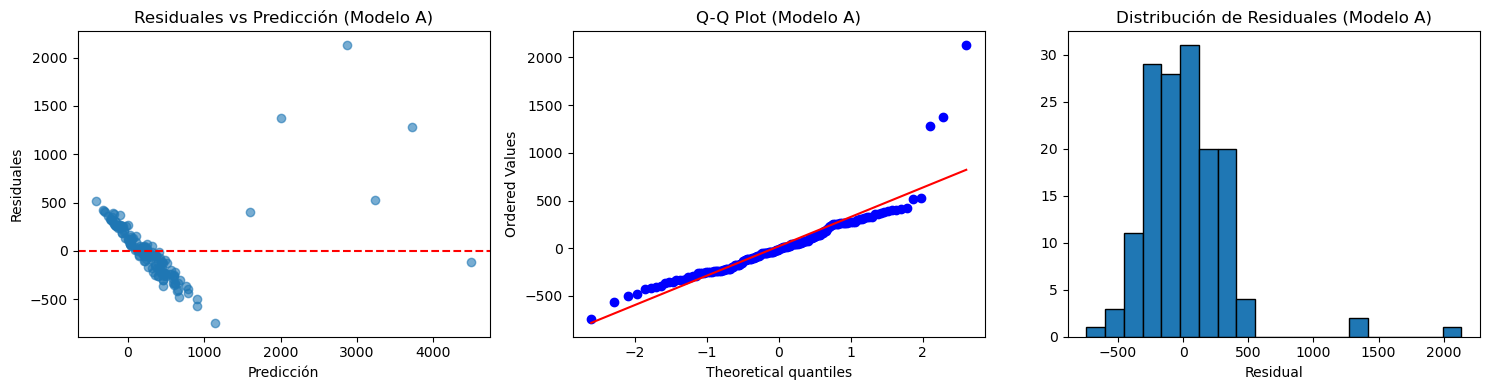

In [11]:
# Diagnósticos para Modelo A
residuals_a = y_test - pred_a

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuales vs predichos
axes[0].scatter(pred_a, residuals_a, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Residuales')
axes[0].set_title('Residuales vs Predicción (Modelo A)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_a, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Modelo A)')

# Histograma de errores
axes[2].hist(residuals_a, bins=20, edgecolor='black')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribución de Residuales (Modelo A)')

plt.tight_layout()
plt.savefig('diagnosticos_modelo_a.png')
plt.show()